In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../utils/')
import plotting_utils as pu
import uproot
import awkward as ak

In [2]:
# Load weights
i0_s1 = np.load('../../weights/of_trial_5/iteration_0_step_1.npz')
i0_s2 = np.load('../../weights/of_trial_5/iteration_0_step_2.npz')
i1_s1 = np.load('../../weights/of_trial_5/iteration_1_step_1.npz')
i1_s2 = np.load('../../weights/of_trial_5/iteration_1_step_2.npz')
i2_s1 = np.load('../../weights/of_trial_5/iteration_2_step_1.npz')
i2_s2 = np.load('../../weights/of_trial_5/iteration_2_step_2.npz')

In [3]:
# Load data
f_train = uproot.open('../../data/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_train_Mar1023.root')
f_test = uproot.open('../../data/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_test_Mar0723.root')
train_tree = f_train['OmniTree']
test_tree = f_test['OmniTree']

In [4]:
# Get pass190 flags
train_pass190 = ak.to_numpy(train_tree['pass190'].array())
test_pass190 = ak.to_numpy(test_tree['pass190'].array())
train_truth_pass190 = ak.to_numpy(train_tree['truth_pass190'].array())
test_truth_pass190 = ak.to_numpy(test_tree['truth_pass190'].array())

In [5]:
# Get source weights
train_source_weights = ak.to_numpy(train_tree['weight'].array())
test_source_weights = ak.to_numpy(test_tree['weight'].array())

In [6]:
# Get Omnifold weights for step 1 iterations
test_i0_s1_all = i0_s1['test'] / test_source_weights
test_i1_s1_all = i1_s1['test'] / test_source_weights
test_i2_s1_all = i2_s1['test'] / test_source_weights
train_i0_s1_all = i0_s1['train'] / train_source_weights
train_i1_s1_all = i1_s1['train'] / train_source_weights
train_i2_s1_all = i2_s1['train'] / train_source_weights

/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:2: RuntimeWarning: invalid value encountered in divide
  test_i0_s1_all = i0_s1['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:3: RuntimeWarning: invalid value encountered in divide
  test_i1_s1_all = i1_s1['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:4: RuntimeWarning: invalid value encountered in divide
  test_i2_s1_all = i2_s1['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:5: RuntimeWarning: invalid value encountered in divide
  train_i0_s1_all = i0_s1['train'] / train_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/4186147926.py:6: RuntimeWarning: invalid value encountered in divide
  train_i1_s1_all = i1_s1['train'] / train_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipyke

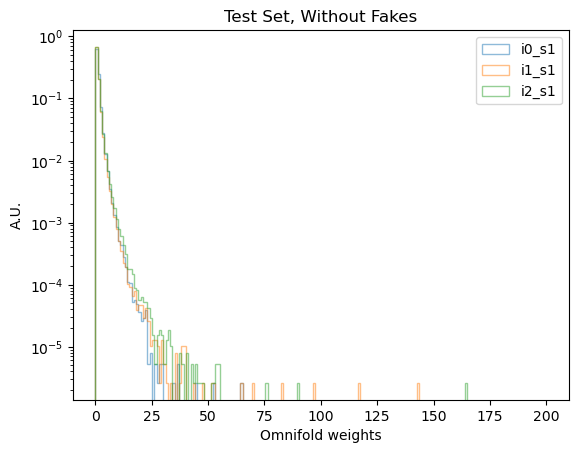

In [12]:
# Make a plot of the i0_s1 and i1_s1 network weights for testing set, with fake events removed
test_i0_s1_no_fakes = test_i0_s1_all[test_pass190 == 1]
test_i1_s1_no_fakes = test_i1_s1_all[test_pass190 == 1]
test_i2_s1_no_fakes = test_i2_s1_all[test_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(test_i0_s1_no_fakes, bins=bins, density=True, histtype='step', label='i0_s1', alpha=0.5)
plt.hist(test_i1_s1_no_fakes, bins=bins, density=True, histtype='step', label='i1_s1', alpha=0.5)
plt.hist(test_i2_s1_no_fakes, bins=bins, density=True, histtype='step', label='i2_s1', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Test Set, Without Fakes')
plt.legend()
plt.show()

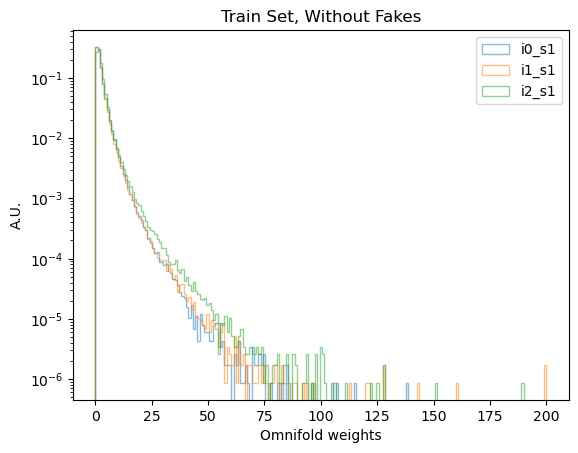

In [11]:
# Make a plot of the i0_s1 and i1_s1 network weights for training set, with fake events removed
train_i0_s1_no_fakes = train_i0_s1_all[train_pass190 == 1]
train_i1_s1_no_fakes = train_i1_s1_all[train_pass190 == 1]
train_i2_s1_no_fakes = train_i2_s1_all[train_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s1_no_fakes, bins=bins, density=True, histtype='step', label='i0_s1', alpha=0.5)
plt.hist(train_i1_s1_no_fakes, bins=bins, density=True, histtype='step', label='i1_s1', alpha=0.5)
plt.hist(train_i2_s1_no_fakes, bins=bins, density=True, histtype='step', label='i2_s1', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Without Fakes')
plt.legend()
plt.show()

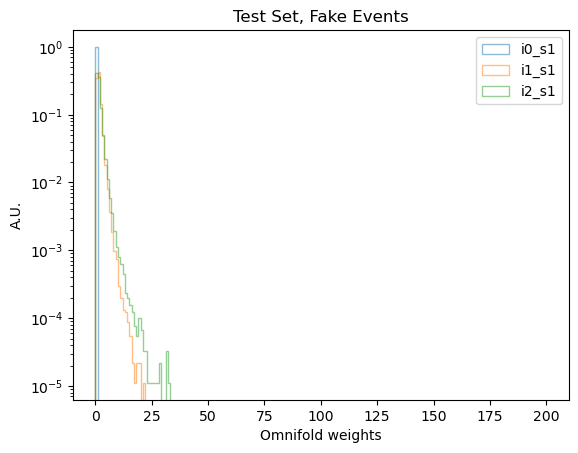

In [15]:
# Make a plot of the i0_s1 and i1_s1 network weights, only fake events
test_i0_s1_fakes = test_i0_s1_all[test_pass190 == 0]
test_i1_s1_fakes = test_i1_s1_all[test_pass190 == 0]
test_i2_s1_fakes = test_i2_s1_all[test_pass190 == 0]
bins = np.linspace(0, 200, 200)
plt.hist(test_i0_s1_fakes, bins=bins, density=True, histtype='step', label='i0_s1', alpha=0.5)
plt.hist(test_i1_s1_fakes, bins=bins, density=True, histtype='step', label='i1_s1', alpha=0.5)
plt.hist(test_i2_s1_fakes, bins=bins, density=True, histtype='step', label='i2_s1', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Test Set, Fake Events')
plt.legend()
plt.show()

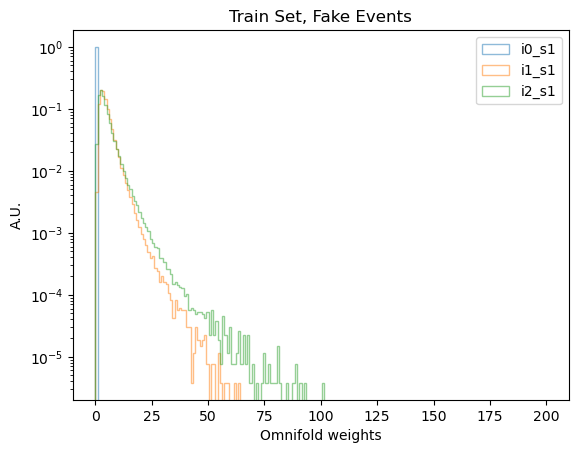

In [14]:
# Make a plot of the i0_s1 and i1_s1 network weights, only fake events
train_i0_s1_fakes = train_i0_s1_all[train_pass190 == 0]
train_i1_s1_fakes = train_i1_s1_all[train_pass190 == 0]
train_i2_s1_fakes = train_i2_s1_all[train_pass190 == 0]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s1_fakes, bins=bins, density=True, histtype='step', label='i0_s1', alpha=0.5)
plt.hist(train_i1_s1_fakes, bins=bins, density=True, histtype='step', label='i1_s1', alpha=0.5)
plt.hist(train_i2_s1_fakes, bins=bins, density=True, histtype='step', label='i2_s1', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Fake Events')
plt.legend()
plt.show()

In [16]:
# Get Omnifold weights for step 2 iterations
test_i0_s2_all = i0_s2['test'] / test_source_weights
test_i1_s2_all = i1_s2['test'] / test_source_weights
test_i2_s2_all = i2_s2['test'] / test_source_weights
train_i0_s2_all = i0_s2['train'] / train_source_weights
train_i1_s2_all = i1_s2['train'] / train_source_weights
train_i2_s2_all = i2_s2['train'] / train_source_weights

/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/2094062495.py:2: RuntimeWarning: invalid value encountered in divide
  test_i0_s2_all = i0_s2['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/2094062495.py:3: RuntimeWarning: invalid value encountered in divide
  test_i1_s2_all = i1_s2['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/2094062495.py:4: RuntimeWarning: invalid value encountered in divide
  test_i2_s2_all = i2_s2['test'] / test_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/2094062495.py:5: RuntimeWarning: invalid value encountered in divide
  train_i0_s2_all = i0_s2['train'] / train_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipykernel_9913/2094062495.py:6: RuntimeWarning: invalid value encountered in divide
  train_i1_s2_all = i1_s2['train'] / train_source_weights
/var/folders/b3/3wj75b155_v5y25br66mw7cm0000gn/T/ipyke

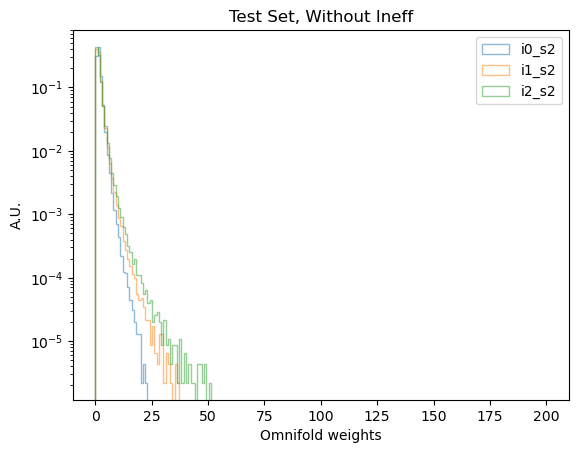

In [17]:
# Make a plot of the i0_s2 and i1_s2 OF weights for testing set, with inefficien events removed
test_i0_s2_no_eff = test_i0_s2_all[test_truth_pass190 == 1]
test_i1_s2_no_eff = test_i1_s2_all[test_truth_pass190 == 1]
test_i2_s2_no_eff = test_i2_s2_all[test_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(test_i0_s2_no_eff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(test_i1_s2_no_eff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(test_i2_s2_no_eff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Test Set, Without Ineff')
plt.legend()
plt.show()

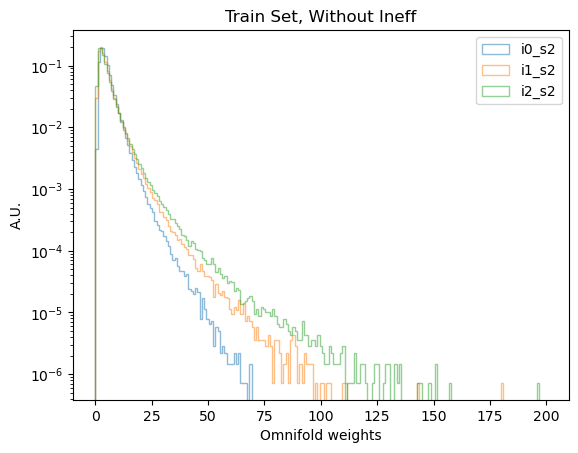

In [18]:
# Make a plot of the i0_s2 and i1_s2 OF weights for training set, with inefficien events removed
train_i0_s2_no_eff = train_i0_s2_all[train_truth_pass190 == 1]
train_i1_s2_no_eff = train_i1_s2_all[train_truth_pass190 == 1]
train_i2_s2_no_eff = train_i2_s2_all[train_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s2_no_eff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(train_i1_s2_no_eff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(train_i2_s2_no_eff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Without Ineff')
plt.legend()
plt.show()

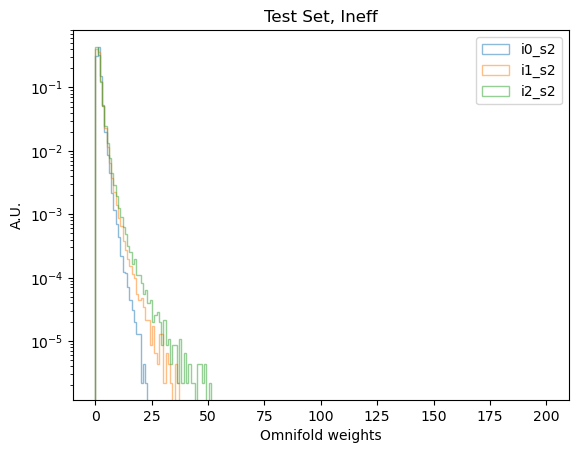

In [19]:
# Make a plot of the i0_s2 and i1_s2 OF weights for the testing set, only ineff
test_i0_s2_ineff = test_i0_s2_all[test_truth_pass190 == 1]
test_i1_s2_ineff = test_i1_s2_all[test_truth_pass190 == 1]
test_i2_s2_ineff = test_i2_s2_all[test_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(test_i0_s2_ineff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(test_i1_s2_ineff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(test_i2_s2_ineff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Test Set, Ineff')
plt.legend()
plt.show()

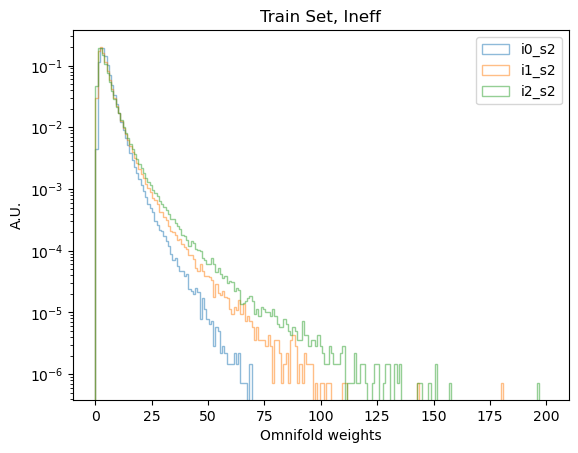

In [20]:
# Make a plot of the i0_s2 and i1_s2 OF weights for the training set, only ineff
train_i0_s2_ineff = train_i0_s2_all[train_truth_pass190 == 1]
train_i1_s2_ineff = train_i1_s2_all[train_truth_pass190 == 1]
train_i2_s2_ineff = train_i2_s2_all[train_truth_pass190 == 1]
bins = np.linspace(0, 200, 200)
plt.hist(train_i0_s2_ineff, bins=bins, density=True, histtype='step', label='i0_s2', alpha=0.5)
plt.hist(train_i1_s2_ineff, bins=bins, density=True, histtype='step', label='i1_s2', alpha=0.5)
plt.hist(train_i2_s2_ineff, bins=bins, density=True, histtype='step', label='i2_s2', alpha=0.5)
plt.yscale('log')
plt.ylabel('A.U.')
plt.xlabel('Omnifold weights')
plt.title('Train Set, Ineff')
plt.legend()
plt.show()